# **IMPORT PACKAGES**

In [1]:
# Core libraries
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

warnings.filterwarnings("ignore")

IMG_SIZE = (200, 200)               # all images are resized to this
LABELS = {0: "Normal", 1: "Lung cancer"}

# **EDA**

In [2]:
# Class label mapping. Folder names under train/ must match these keys.
classes = {"Normal": 0, "Lung cancer": 1}
print("Classes:", classes)

Classes: {'Normal': 0, 'Lung cancer': 1}


# **TRAINING DATASET**

In [3]:
# Load every training image as grayscale, resize, and build feature/label arrays.
X, Y = [], []
for cls, label in classes.items():
    folder = os.path.join("train", cls)
    for fname in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue  # skip unreadable files
        X.append(cv2.resize(img, IMG_SIZE))
        Y.append(label)

X = np.array(X)
Y = np.array(Y)
print("Loaded", len(X), "images.")

Loaded 615 images.


Images per class:
Normal         416
Lung cancer    199
Name: count, dtype: int64

Image tensor: (615, 200, 200) -> flattened: (615, 40000)


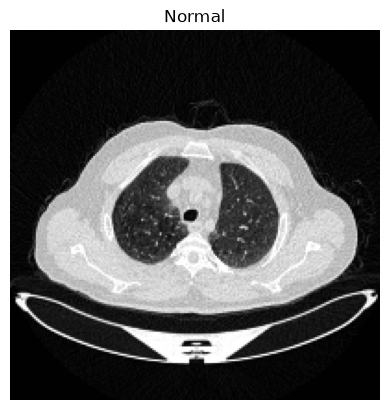

Train: (492, 40000) Test: (123, 40000)


In [4]:
# Flatten each image into a 1-D feature vector (200*200 = 40000 features).
X_updated = X.reshape(len(X), -1)

print("Images per class:")
print(pd.Series(Y).map({v: k for k, v in classes.items()}).value_counts())
print("\nImage tensor:", X.shape, "-> flattened:", X_updated.shape)

# Preview one sample.
plt.imshow(X[0], cmap="gray")
plt.title(LABELS[int(Y[0])])
plt.axis("off")
plt.show()

# Train/test split (80/20), stratified so both classes appear in each split.
xtrain, xtest, ytrain, ytest = train_test_split(
    X_updated, Y, test_size=0.20, random_state=10, stratify=Y
)
print("Train:", xtrain.shape, "Test:", xtest.shape)

In [5]:
# Scale pixel values from [0, 255] to [0, 1].
print("Before:", xtrain.min(), "-", xtrain.max())
xtrain = xtrain / 255.0
xtest = xtest / 255.0
print("After: ", xtrain.min(), "-", xtrain.max())

Before: 0 - 255
After:  0.0 - 1.0


In [6]:
# Ensemble of Logistic Regression + SVM using hard (majority) voting.
lr = LogisticRegression(C=0.1)
svm = SVC()
cmodel = VotingClassifier(estimators=[("lr", lr), ("svm", svm)], voting="hard")
cmodel.fit(xtrain, ytrain)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svm', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegression(C=0.1), SVC()]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,40000


In [7]:
# Save the trained model to the repo root so predict.py and the web app can load it.
joblib.dump(cmodel, "CModel.pkl")
print("Saved CModel.pkl")

Saved CModel.pkl


In [8]:
# Evaluate on the held-out test set.
pred = cmodel.predict(xtest)
print("Test accuracy:", round(accuracy_score(ytest, pred), 4))
print()
print(classification_report(ytest, pred, target_names=["Normal", "Lung cancer"]))
print("Confusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(ytest, pred))

Test accuracy: 1.0

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        83
 Lung cancer       1.00      1.00      1.00        40

    accuracy                           1.00       123
   macro avg       1.00      1.00      1.00       123
weighted avg       1.00      1.00      1.00       123

Confusion matrix (rows = actual, cols = predicted):
[[83  0]
 [ 0 40]]


# Find misclassified samples

In [9]:
misclassified = np.where(ytest != pred)

# Print total misclassified samples

In [10]:
print("\nTotal Misclassified Samples: ", len(misclassified[0]))
print("Prediction for the 36th sample:", pred[36])
print("Actual label for the 36th sample:", ytest[36])


Total Misclassified Samples:  0
Prediction for the 36th sample: 1
Actual label for the 36th sample: 1


# Define a dictionary for decoding labels

In [11]:
dec = LABELS  # decode numeric predictions to label strings

# Plotting 1

In [12]:
plt.figure(figsize=(12, 8))
p = os.listdir(r'Testing')
c = 1

<Figure size 1200x800 with 0 Axes>

# Visualizing Predictions on Normal  Images

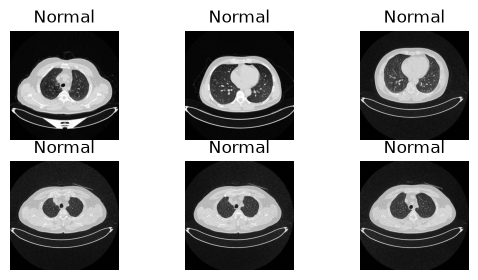

In [13]:
for i in os.listdir(r'Testing/Normal/')[:6]:
    plt.subplot(3,3,c)

    img = cv2.imread(r'Testing/Normal/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = cmodel.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1

# Plotting 2

In [14]:
plt.figure(figsize=(12,8))
p = os.listdir(r'Testing/')
c=1


<Figure size 1200x800 with 0 Axes>

# Visualizing Predictions on Cancer Images

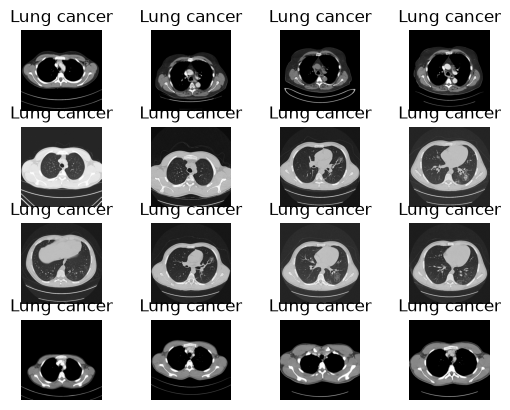

In [15]:
for i in os.listdir(r'Testing/Lung cancer/')[:16]:
    plt.subplot(4,4,c)

    img = cv2.imread(r'Testing/Lung cancer/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = cmodel.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1


# **FINDING FOR NEW IMAGE**

In [16]:
def classify_single_image(image_path, model=None):
    """Classify a single image path as 'Normal' or 'Lung cancer'."""
    model = model if model is not None else joblib.load("CModel.pkl")
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    img = cv2.resize(img, IMG_SIZE)
    features = img.reshape(1, -1) / 255.0
    return LABELS[int(model.predict(features)[0])]

In [17]:
image_path = r'Testing\Normal\Normal case (3).jpg'
prediction = classify_single_image(image_path)
print("Prediction for", image_path, ":", prediction)

Prediction for Testing\Normal\Normal case (3).jpg : Normal
